# Book Genre Multi Label Text Classification (text-based)
### Group Members: 
##### Kornel Zaleski X00222004 
##### Lukasz Kiraga X00227628 
##### Blessing Mayindu X00224444
##### Goal: The goal for this project is to predict the book genre based on its summary.

In [1]:
# !pip install numpy
# !pip install matplotlib
# !pip install scikit-learn
# !pip install pandas 
# !pip install tensorflow
# !pip install pandas 
# !pip install tabulate

## 1. Importing Necessary Libraries

In [2]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import joblib
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
import os


## 2.  Data Exploration

### Analysing data through the three datasets

In [3]:
# BooksDataset.csv - df1
df1 = pd.read_csv('BooksDataset.csv')
print("BooksDataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df1.shape)
print("Columns: ", df1.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df1.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df1.info(), "\n")
print("\n" + ("-"*30), "\n")

# goodreads_data.csv - df2
df2 = pd.read_csv('goodreads_data.csv')
print("goodreads_data.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df2.shape)
print("Columns: ", df2.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df2.describe(include='all'), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df2.info(), "\n")
print("\n" + ("-"*30), "\n")

# google_books_dataset.csv - df3
df3 = pd.read_csv('google_books_dataset.csv')
print("google_books_dataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df3.shape)
print("Columns: ", df3.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df3.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df3.info())
print("\n" + ("-"*30), "\n")

# Number of nulls in not cleaned datasets
print("\nNull values in each uncleaned dataset\n")
print("Number of null values in BooksDataset.csv")
nulls_df1og = df1.isnull().sum()
print(nulls_df1og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in goodreads_data.csv")
nulls_df2og = df2.isnull().sum()
print(nulls_df2og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in google_books_dataset.csv")
nulls_df3og = df3.isnull().sum()
print(nulls_df3og)
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each not cleaned dataset for checking that cleaning worked as intended (checking if nan values are removed)
print("BooksDataset.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("goodreads_data.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("google_books_dataset.csv\n\n", df3.head(15).to_markdown(index=False), "\n")

BooksDataset.csv loaded successfully.

-----------Dataset Shape & Columns-----------

Shape:  (103082, 5)
Columns:  ['Title', 'Author', 'Description', 'Category', 'Publisher']

-----------Description of dataset columns-----------

                 Title  Author  \
count           103082  102990   
unique           97813   63579   
top     The Nutcracker      By   
freq                12    1043   

                                              Description  \
count                                               70213   
unique                                              68831   
top     For Ingest Only - Data needs to be cleaned up ...   
freq                                                   30   

                    Category         Publisher  
count                  76911            103074  
unique                  3106             13029  
top     "Fiction", "General"  Simon & Schuster  
freq                    2549              1521   


-----------Dataset Overall Info-----------



## 3. Data Cleaning
### Each dataset will be cleaned before merging

In [4]:
# Load and save the cleaned datasets

# BooksDataset.csv - df1
df1 = df1.dropna(subset=['Title', 'Description', 'Category'], how='any')
df1 = df1.drop_duplicates()
#df1.to_csv('BooksDatasetClean.csv', encoding="utf-8", index=False)

# goodreads_data.csv - df2
df2 = df2.dropna(subset=['Title', 'Description', 'Genres'], how='any')
df2 = df2.drop_duplicates()
#df2.to_csv('GoodreadsDatasetClean.csv', encoding="utf-8", index=False)

# google_books_dataset.csv - df3
df3 = df3.dropna(subset=['Title', 'Description', 'Category'], how='any')
df3 = df3.drop_duplicates()
#df3.to_csv('GoogleBooksDatasetClean.csv', encoding="utf-8", index=False)

# Number of nulls in cleaned datasets
print("\nNull values in each cleaned dataset\n")
print("Number of null values in BooksDatasetClean.csv")
nulls_df1 = df1.isnull().sum()
print(nulls_df1)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoodreadsDatasetClean.csv")
nulls_df2 = df2.isnull().sum()
print(nulls_df2)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoogleBooksDatasetClean.csv")
nulls_df3 = df3.isnull().sum()
print(nulls_df3)
print("\n" + ("-"*30), "\n")

# Nulls in each uncleaned and cleaned datasets comparison
print("\nNull values comparison (uncleaned vs cleaned)\n")
print("BooksDataset.csv vs BooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df1og, 'Cleaned': nulls_df1}), "\n")
print("\n" + ("-"*30), "\n")
print("goodreads_data.csv vs GoodreadsDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df2og, 'Cleaned': nulls_df2}), "\n")
print("\n" + ("-"*30), "\n")
print("google_books_dataset.csv vs GoogleBooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df3og, 'Cleaned': nulls_df3}), "\n")
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each cleaned dataset to ensure the cleaning process
print("BooksDatasetClean.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("GoodreadsDatasetClean.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("GoogleBooksDatasetClean.csv\n\n", df3.head(15).to_markdown(index=False), "\n")


Null values in each cleaned dataset

Number of null values in BooksDatasetClean.csv
Title           0
Author         11
Description     0
Category        0
Publisher       0
dtype: int64

------------------------------ 


Number of null values in GoodreadsDatasetClean.csv
Title          0
Author         0
Description    0
Genres         0
Avg Rating     0
Num Ratings    0
dtype: int64

------------------------------ 


Number of null values in GoogleBooksDatasetClean.csv
Title                 0
Subtitle           3565
Author              299
Publisher          1135
Description           0
Category              0
Search Category       0
dtype: int64

------------------------------ 


Null values comparison (uncleaned vs cleaned)

BooksDataset.csv vs BooksDatasetClean.csv
              Uncleaned  Cleaned
Title                0        0
Author              92       11
Description      32869        0
Category         26171        0
Publisher            8        0 


----------------------

## 4. Data merging


In [5]:

# Merging two csv files

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

final_df = pd.concat(
    [df1[common_columns], df2[common_columns], df3[common_columns]],
    ignore_index=True
)

print(final_df.head())
# Here I am showing that the columns have difference headers . To fix this I need to make them the same and then put them together.
print("DF1 columns:")
print(df1.columns.tolist())

print("\nDF2 columns:")
print(df2.columns.tolist())

print("\nDF3 columns:")
print(df3.columns.tolist())

# Making all the columns lowercase
for df in [df1, df2, df3]:
    df.columns = df.columns.str.lower().str.strip()

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)
print(common_columns)

                                               Title  \
0                         Journey Through Heartsongs   
1                       In Search of Melancholy Baby   
2       The Dieter's Guide to Weight Loss During Sex   
3  Germs : Biological Weapons and America's Secre...   
4  The Good Book: Reading the Bible with Mind and...   

                                              Author  \
0                             Stepanek, Mattie J. T.   
1  Aksyonov, Vassily, Heim, Michael Henry, and Bo...   
2                                     Smith, Richard   
3  Miller, Judith, Engelberg, Stephen, and Broad,...   
4                                    Gomes, Peter J.   

                                         Description  
0  Collects poems written the eleven-year-old mus...  
1  The Russian author offers an affectionate chro...  
2  A humor classic, this tongue-in-cheek diet pla...  
3  Deadly germs sprayed in shopping malls, bomb-l...  
4  "The Bible and the social and moral consequenc..

In [7]:
#Here I am matching header names to the df3 
#pandas.DataFrame.rename

dfs = []
for df_loop in [df1, df2, df3]:
    df_loop.columns = df_loop.columns.str.lower().str.strip()
    dfs.append(df_loop)

df1,df2,df3 = dfs

df2 = df2.rename(columns={
    "book": "title",
    "author": "authors",
    "genres": "categories"
})

df1 = df1.rename(columns={
    "category": "categories",
    "author": "authors"
})
#df1 = df1.rename(columns={"categories": "category"})
#df2 = df2.rename(columns={"categories": "category"})
#df3 = df3.rename(columns={"categories": "category"})

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

print("\nCommon columns:", common_columns)
# Merge
df = pd.concat([df1, df2, df3], ignore_index=True)
df.to_csv('MergedBooksDataset.csv', encoding="utf-8", index=False)

print("\nFinal merged dataset:")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())
print("\n-----------Dataset First and Last 15 rows-----------\n")
print("First 15 rows\n\n", df.head(15).to_markdown(index=False), "\n")
print("Last 15 rows\n\n", df.tail(15).to_markdown(index=False), "\n")
print("\n-----------Description of dataset columns-----------\n")
print(df.describe(), "\n")
print("\n" + ("-"*30), "\n")
print("\nNumber of categories: ")
print(df["category"].value_counts().to_string())
print("\n-----------Dataset Overall Info-----------\n")
print(df.info())



Common columns: Index(['title', 'description'], dtype='str')

Final merged dataset:

-----------Dataset Shape & Columns-----------

Shape:  (82522, 11)
Columns:  ['title', 'authors', 'description', 'categories', 'publisher', 'avg rating', 'num ratings', 'subtitle', 'author', 'category', 'search category']

-----------Dataset First and Last 15 rows-----------

First 15 rows

 | title                                                                  | authors                                                                 | description                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

### Data Visualisation - Categories

##### Using a bar chart from matplotlib, it will show the top 10 categories that are most frequently occurring in the merged dataset

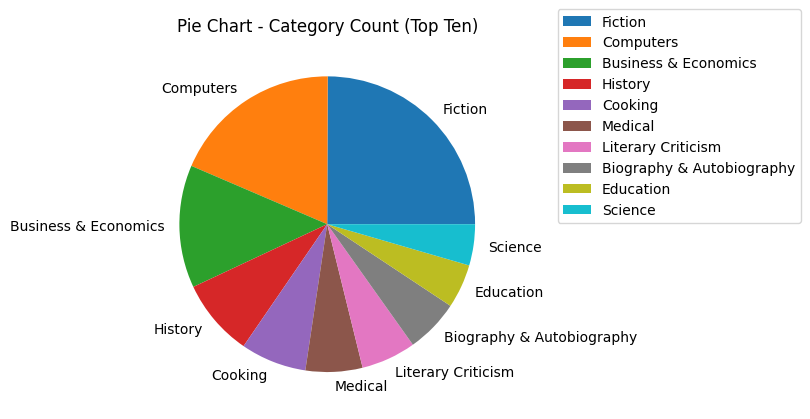

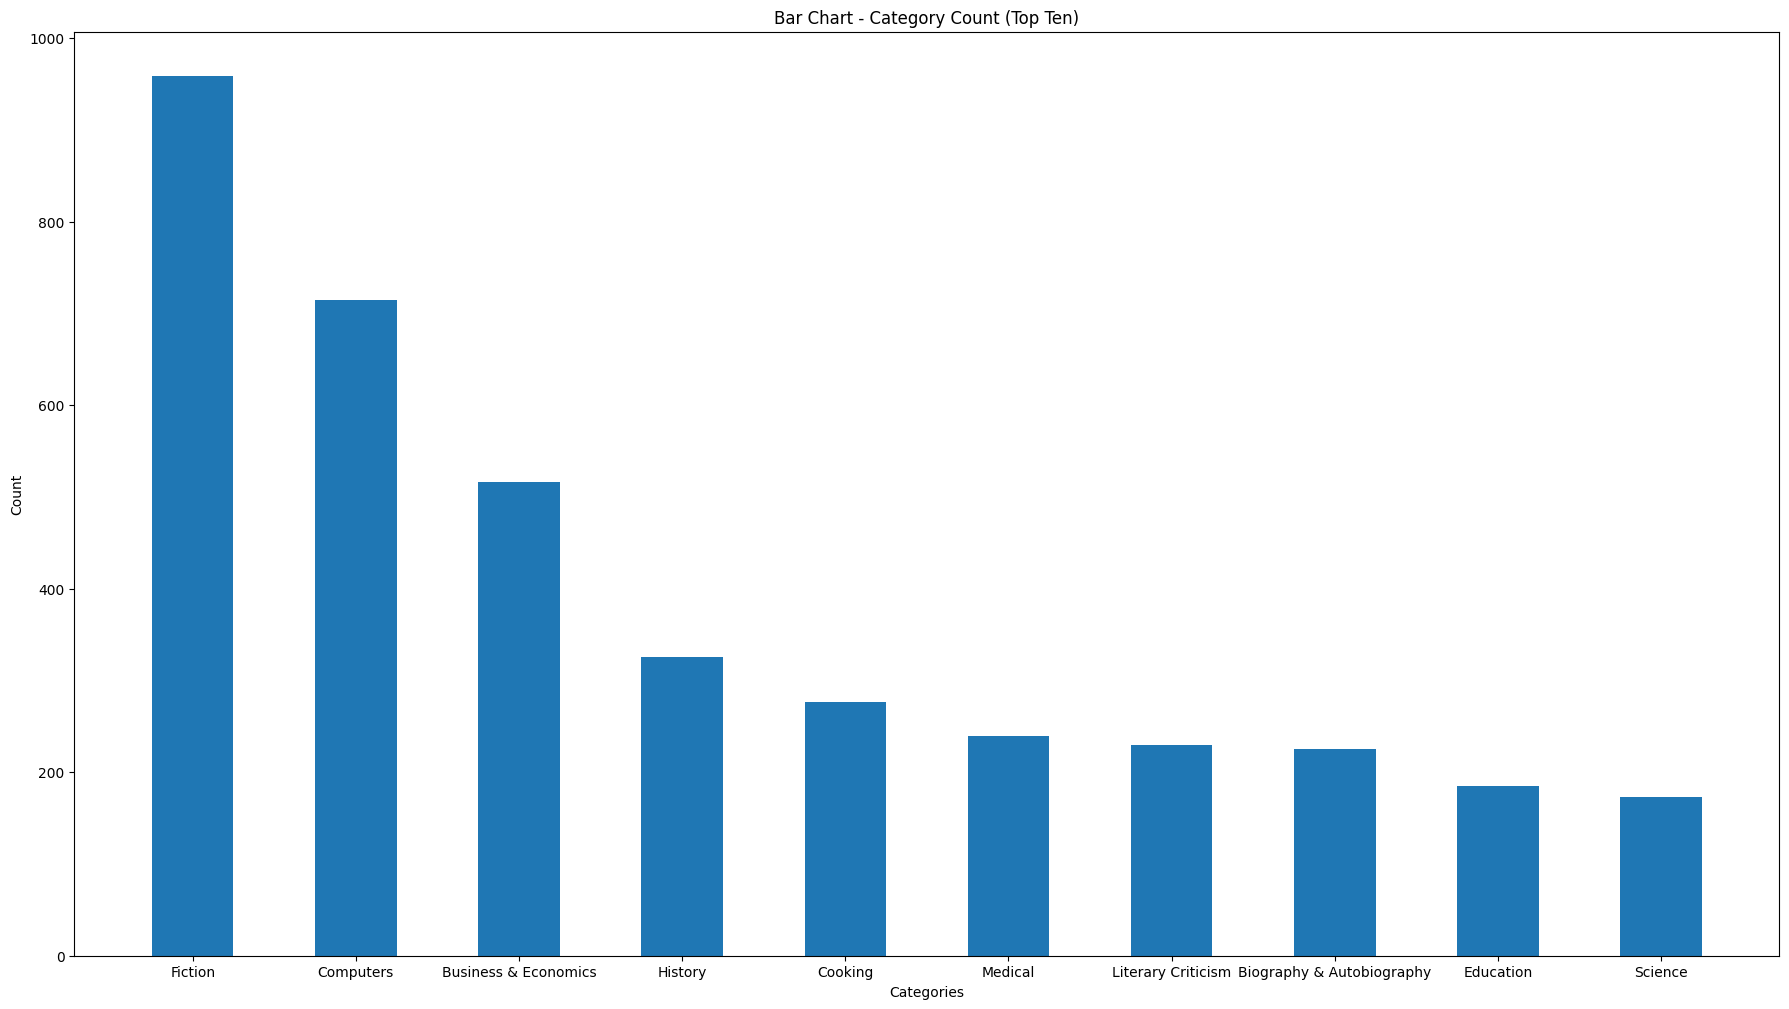

In [87]:
categories = df["category"].value_counts().head(10).index.tolist()
count = df["category"].value_counts().head(10).values.tolist()
new_categories = []

for category in categories:
    category = category.replace('"', '')
    new_categories.append(category)
    
categories = new_categories

plt.pie(count, labels=categories)
plt.title("Pie Chart - Category Count (Top Ten)")
plt.legend(categories, loc="upper right", bbox_to_anchor=(1.7, 1, 0.1, 0.1))
plt.show()

plt.figure(figsize=(22, 12))
plt.bar(categories, count, width=0.5)
plt.title("Bar Chart - Category Count (Top Ten)")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.show()

## 5. Feature Selection

In [38]:
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(df)
print('\nidf values:') 
for ele1, ele2 in zip(tfidf.get_feature_names_out(),
tfidf.idf_): print(ele1, ':', ele2) 
print('\nWord indexes:') 
print(tfidf.vocabulary_)
print('\ntf-idf value:') 
print(result) 
print('\ntf-idf values in matrix form:') 
print(result.toarray())


idf values:
author : 2.791759469228055
authors : 2.791759469228055
avg : 2.791759469228055
categories : 2.791759469228055
category : 2.386294361119891
description : 2.791759469228055
num : 2.791759469228055
publisher : 2.791759469228055
rating : 2.791759469228055
ratings : 2.791759469228055
search : 2.791759469228055
subtitle : 2.791759469228055
title : 2.791759469228055

Word indexes:
{'title': 12, 'authors': 1, 'description': 5, 'categories': 3, 'publisher': 7, 'avg': 2, 'rating': 8, 'num': 6, 'ratings': 9, 'subtitle': 11, 'author': 0, 'category': 4, 'search': 10}

tf-idf value:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14 stored elements and shape (11, 13)>
  Coords	Values
  (0, 12)	1.0
  (1, 1)	1.0
  (2, 5)	1.0
  (3, 3)	1.0
  (4, 7)	1.0
  (5, 2)	0.7071067811865476
  (5, 8)	0.7071067811865476
  (6, 6)	0.7071067811865476
  (6, 9)	0.7071067811865476
  (7, 11)	1.0
  (8, 0)	1.0
  (9, 4)	1.0
  (10, 4)	0.6497481581610048
  (10, 10)	0.7601495451333123

tf-idf values in